# FASE 0 - Alcance del Analisis exploratorio de los datos

# FASE 1 - Contexto Clinico y origen de los datos

# Fase 2 - Cargar base de datos

En esta fase se carga oficialmente el dataset asignado al grupo: **PathMNIST**, correspondiente al dataset número 5 de la rúbrica del proyecto.

El objetivo de esta fase es verificar que el notebook esté trabajando con la fuente correcta de datos antes de iniciar el análisis exploratorio profundo.

Se comprobará que:

- El dataset cargado sea PathMNIST.
- La resolución utilizada sea 28x28.
- Las imágenes correspondan a una modalidad RGB de 3 canales.
- La tarea sea de clasificación multiclase.
- Se utilicen los splits oficiales de MedMNIST: train, validation y test.

Esta fase no analiza todavía distribución de clases, calidad visual, rangos de píxeles ni estadísticas RGB. Esos análisis se desarrollarán en fases posteriores del EDA.

## Instalación e importación de librerías

In [ ]:
#!pip install -q medmnist

import random
import numpy as np
import pandas as pd
import torch
import medmnist

from medmnist import INFO
from medmnist import PathMNIST
from IPython.display import display

## Configuración base del proyecto

In [2]:
SEED = 42

DATA_FLAG = "pathmnist"
DATASET_NAME = "PathMNIST"

EXPECTED_IMAGE_SIZE = 28
EXPECTED_CHANNELS = 3
EXPECTED_TASK = "multi-class"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Configuración base del proyecto")
print(f"Seed: {SEED}")
print(f"Dataset seleccionado: {DATASET_NAME}")
print(f"Identificador MedMNIST: {DATA_FLAG}")
print(f"Resolución esperada: {EXPECTED_IMAGE_SIZE}x{EXPECTED_IMAGE_SIZE}")
print(f"Canales esperados: {EXPECTED_CHANNELS}")
print(f"Tarea esperada: {EXPECTED_TASK}")

Configuración base del proyecto
Seed: 42
Dataset seleccionado: PathMNIST
Identificador MedMNIST: pathmnist
Resolución esperada: 28x28
Canales esperados: 3
Tarea esperada: multi-class


## Consulta de metadatos oficiales de PathMNIST

In [3]:
info = INFO[DATA_FLAG]

task = info["task"]
n_channels = info["n_channels"]
class_labels = info["label"]
n_classes = len(class_labels)
n_samples = info["n_samples"]

metadata_df = pd.DataFrame({
    "Atributo": [
        "Dataset",
        "Identificador MedMNIST",
        "Tarea",
        "Número de canales",
        "Número de clases",
        "Splits disponibles",
        "Resolución utilizada en esta entrega"
    ],
    "Valor": [
        DATASET_NAME,
        DATA_FLAG,
        task,
        n_channels,
        n_classes,
        list(n_samples.keys()),
        f"{EXPECTED_IMAGE_SIZE}x{EXPECTED_IMAGE_SIZE}"
    ]
})

display(metadata_df)

,Atributo,Valor
0,Dataset,PathMNIST
1,Identificador MedMNIST,pathmnist
2,Tarea,multi-class
3,Número de canales,3
4,Número de clases,9
5,Splits disponibles,"[train, val, test]"
6,Resolución utilizada en esta entrega,28x28


## Tabla oficial de clases

In [4]:
classes_df = pd.DataFrame({
    "class_id": [int(class_id) for class_id in class_labels.keys()],
    "class_name": list(class_labels.values())
})

classes_df = classes_df.sort_values("class_id").reset_index(drop=True)

display(classes_df)

,class_id,class_name
0,0,adipose
1,1,background
2,2,debris
3,3,lymphocytes
4,4,mucus
5,5,smooth muscle
6,6,normal colon mucosa
7,7,cancer-associated stroma
8,8,colorectal adenocarcinoma epithelium


## Carga oficial de los splits

In [5]:
train_dataset = PathMNIST(split="train", download=True)
val_dataset = PathMNIST(split="val", download=True)
test_dataset = PathMNIST(split="test", download=True)

datasets = {
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
}

split_summary_df = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "num_images": [
        len(train_dataset),
        len(val_dataset),
        len(test_dataset)
    ]
})

display(split_summary_df)

,split,num_images
0,train,89996
1,validation,10004
2,test,7180


## Verificación mínima de carga

In [6]:
expected_split_sizes = {
    "train": n_samples["train"],
    "validation": n_samples["val"],
    "test": n_samples["test"]
}

loaded_split_sizes = {
    "train": len(train_dataset),
    "validation": len(val_dataset),
    "test": len(test_dataset)
}

verification_rows = []

for split_name in expected_split_sizes:
    verification_rows.append({
        "split": split_name,
        "expected_size": expected_split_sizes[split_name],
        "loaded_size": loaded_split_sizes[split_name],
        "matches_expected": expected_split_sizes[split_name] == loaded_split_sizes[split_name]
    })

verification_df = pd.DataFrame(verification_rows)

display(verification_df)

,split,expected_size,loaded_size,matches_expected
0,train,89996,89996,True
1,validation,10004,10004,True
2,test,7180,7180,True


## Validaciones automáticas mínimas

In [7]:
assert task == EXPECTED_TASK, (
    f"La tarea cargada no coincide con la esperada. "
    f"Esperado: {EXPECTED_TASK}. Obtenido: {task}."
)

assert n_channels == EXPECTED_CHANNELS, (
    f"El número de canales no coincide. "
    f"Esperado: {EXPECTED_CHANNELS}. Obtenido: {n_channels}."
)

assert n_classes == 9, (
    f"El número de clases no coincide. "
    f"Esperado: 9. Obtenido: {n_classes}."
)

for split_name in expected_split_sizes:
    assert expected_split_sizes[split_name] == loaded_split_sizes[split_name], (
        f"El tamaño del split {split_name} no coincide. "
        f"Esperado: {expected_split_sizes[split_name]}. "
        f"Obtenido: {loaded_split_sizes[split_name]}."
    )

sample_shape = train_dataset.imgs.shape[1:]

assert sample_shape == (EXPECTED_IMAGE_SIZE, EXPECTED_IMAGE_SIZE, EXPECTED_CHANNELS), (
    f"La forma de imagen no coincide con la resolución esperada. "
    f"Esperado: ({EXPECTED_IMAGE_SIZE}, {EXPECTED_IMAGE_SIZE}, {EXPECTED_CHANNELS}). "
    f"Obtenido: {sample_shape}."
)

print("Carga verificada correctamente.")
print(f"Forma interna del split train: {train_dataset.imgs.shape}")
print(f"Forma esperada por imagen: ({EXPECTED_IMAGE_SIZE}, {EXPECTED_IMAGE_SIZE}, {EXPECTED_CHANNELS})")

Carga verificada correctamente.
Forma interna del split train: (89996, 28, 28, 3)
Forma esperada por imagen: (28, 28, 3)


## Conclusión de la Fase 2

Se cargó correctamente el dataset **PathMNIST** mediante la API oficial de MedMNIST.

La verificación mínima confirma que se está trabajando con:

- Dataset correcto: PathMNIST.
- Resolución correcta: 28x28.
- Modalidad correcta: imágenes RGB de 3 canales.
- Tarea correcta: clasificación multiclase.
- Número de clases: 9.
- Splits oficiales: train, validation y test.

Los tamaños cargados coinciden con los metadatos oficiales del dataset:

- Train: 89.996 imágenes.
- Validation: 10.004 imágenes.
- Test: 7.180 imágenes.

Con esto, el dataset queda preparado para la siguiente etapa del EDA.

# Fase 3 -  Auditoría estructural de datos

En esta fase se realiza una auditoría estructural de los datos cargados en la fase anterior.

El objetivo es verificar la consistencia interna de los tres splits oficiales de PathMNIST:

- Train.
- Validation.
- Test.

Se revisarán:

- Dimensiones de imágenes.
- Dimensiones de etiquetas.
- Tipos de datos.
- Rango de valores de píxeles.
- Cantidad de imágenes y etiquetas.
- Formato de las etiquetas.
- Clases únicas presentes.
- Coherencia general entre imágenes, etiquetas y metadatos oficiales.

Esta fase no analiza todavía la distribución de clases ni realiza visualización de imágenes. Esos pasos se desarrollarán en las fases posteriores del EDA.

## Función de inspección estructural por split

In [8]:
def inspect_dataset_structure(dataset, split_name):
    """
    Inspecciona la estructura básica de un split de PathMNIST.
    
    Parámetros:
    dataset: objeto PathMNIST correspondiente a train, validation o test.
    split_name: nombre del split.
    
    Retorna:
    Diccionario con información estructural del split.
    """
    
    images = dataset.imgs
    labels = dataset.labels
    
    return {
        "split": split_name,
        "images_shape": images.shape,
        "labels_shape": labels.shape,
        "images_dtype": images.dtype,
        "labels_dtype": labels.dtype,
        "num_images": images.shape[0],
        "num_labels": labels.shape[0],
        "height": images.shape[1],
        "width": images.shape[2],
        "channels": images.shape[3] if images.ndim == 4 else None,
        "pixel_min": images.min(),
        "pixel_max": images.max(),
        "pixel_mean": images.mean(),
        "pixel_std": images.std()
    }

## Aplicación de la auditoría estructural

In [9]:
structure_rows = []

for split_name, dataset in datasets.items():
    structure_rows.append(inspect_dataset_structure(dataset, split_name))

structure_df = pd.DataFrame(structure_rows)

display(structure_df)

,split,images_shape,labels_shape,images_dtype,labels_dtype,num_images,num_labels,height,width,channels,pixel_min,pixel_max,pixel_mean,pixel_std
0,train,"(89996, 28, 28, 3)","(89996, 1)",uint8,uint8,89996,89996,28,28,3,0,255,168.245264,43.361609
1,validation,"(10004, 28, 28, 3)","(10004, 1)",uint8,uint8,10004,10004,28,28,3,0,255,168.549933,43.326589
2,test,"(7180, 28, 28, 3)","(7180, 1)",uint8,uint8,7180,7180,28,28,3,0,255,167.573598,49.025201


## Verificación de correspondencia entre imágenes y etiquetas

In [10]:
image_label_consistency_rows = []

for split_name, dataset in datasets.items():
    num_images = dataset.imgs.shape[0]
    num_labels = dataset.labels.shape[0]
    
    image_label_consistency_rows.append({
        "split": split_name,
        "num_images": num_images,
        "num_labels": num_labels,
        "matches": num_images == num_labels
    })

image_label_consistency_df = pd.DataFrame(image_label_consistency_rows)

display(image_label_consistency_df)

,split,num_images,num_labels,matches
0,train,89996,89996,True
1,validation,10004,10004,True
2,test,7180,7180,True


## Inspección del formato de etiquetas

In [11]:
label_format_rows = []

for split_name, dataset in datasets.items():
    labels = dataset.labels
    
    label_format_rows.append({
        "split": split_name,
        "labels_shape": labels.shape,
        "labels_ndim": labels.ndim,
        "second_dimension": labels.shape[1] if labels.ndim == 2 else None,
        "labels_dtype": labels.dtype
    })

label_format_df = pd.DataFrame(label_format_rows)

display(label_format_df)

,split,labels_shape,labels_ndim,second_dimension,labels_dtype
0,train,"(89996, 1)",2,1,uint8
1,validation,"(10004, 1)",2,1,uint8
2,test,"(7180, 1)",2,1,uint8


## Etiquetas únicas por split

In [12]:
unique_label_rows = []

for split_name, dataset in datasets.items():
    labels = dataset.labels.reshape(-1)
    unique_labels = np.unique(labels)
    
    unique_label_rows.append({
        "split": split_name,
        "num_unique_labels": len(unique_labels),
        "unique_labels": unique_labels.tolist(),
        "min_label": int(unique_labels.min()),
        "max_label": int(unique_labels.max())
    })

unique_labels_df = pd.DataFrame(unique_label_rows)

display(unique_labels_df)

,split,num_unique_labels,unique_labels,min_label,max_label
0,train,9,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",0,8
1,validation,9,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",0,8
2,test,9,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",0,8


## Validación automática de estructura

In [13]:
for split_name, dataset in datasets.items():
    images = dataset.imgs
    labels = dataset.labels
    
    assert images.ndim == 4, (
        f"Error en {split_name}: se esperaba images.ndim == 4, "
        f"pero se obtuvo {images.ndim}."
    )
    
    assert images.shape[1:] == (EXPECTED_IMAGE_SIZE, EXPECTED_IMAGE_SIZE, EXPECTED_CHANNELS), (
        f"Error en {split_name}: se esperaba forma por imagen "
        f"({EXPECTED_IMAGE_SIZE}, {EXPECTED_IMAGE_SIZE}, {EXPECTED_CHANNELS}), "
        f"pero se obtuvo {images.shape[1:]}."
    )
    
    assert labels.ndim == 2, (
        f"Error en {split_name}: se esperaba labels.ndim == 2, "
        f"pero se obtuvo {labels.ndim}."
    )
    
    assert labels.shape[1] == 1, (
        f"Error en {split_name}: se esperaba labels.shape[1] == 1, "
        f"pero se obtuvo {labels.shape[1]}."
    )
    
    assert images.shape[0] == labels.shape[0], (
        f"Error en {split_name}: el número de imágenes y etiquetas no coincide. "
        f"Imágenes: {images.shape[0]}, etiquetas: {labels.shape[0]}."
    )
    
    flat_labels = labels.reshape(-1)
    
    assert flat_labels.min() >= 0, (
        f"Error en {split_name}: existe una etiqueta menor que 0."
    )
    
    assert flat_labels.max() < n_classes, (
        f"Error en {split_name}: existe una etiqueta fuera del rango esperado."
    )
    
    assert images.min() >= 0, (
        f"Error en {split_name}: existen valores de píxel menores que 0."
    )
    
    assert images.max() <= 255, (
        f"Error en {split_name}: existen valores de píxel mayores que 255."
    )

print("Validación estructural superada correctamente en train, validation y test.")

Validación estructural superada correctamente en train, validation y test.


## Conclusión de la Fase 3

La auditoría estructural confirma que los tres splits oficiales de PathMNIST presentan una estructura interna consistente.

Las imágenes de train, validation y test se encuentran almacenadas con formato `[N, 28, 28, 3]`, lo que confirma que corresponden a imágenes RGB de 28x28 píxeles. Además, las etiquetas presentan formato `[N, 1]`, consistente con una tarea de clasificación multiclase single-label.

También se verificó que el número de imágenes coincide exactamente con el número de etiquetas en los tres splits. Los valores de píxeles se encuentran dentro del rango esperado para imágenes digitales sin normalizar, entre 0 y 255, y las etiquetas presentes corresponden al rango válido de clases, desde 0 hasta 8.

Un aspecto técnico relevante para etapas posteriores es que las imágenes están almacenadas en formato `channels-last`, es decir, `[N, H, W, C]`. Este formato puede requerir distintas adaptaciones según la herramienta de modelado utilizada. Por ejemplo, en TensorFlow/Keras este formato suele ser compatible de forma directa, mientras que en PyTorch/torchvision normalmente se requiere transformar las imágenes a formato `channels-first`, es decir, `[N, C, H, W]`. En métodos clásicos de machine learning, como modelos implementados con scikit-learn, las imágenes suelen aplanarse a vectores de características.


# Fase 4 - Distribución de clases

En esta fase se analiza la distribución de clases en los tres splits oficiales de PathMNIST:

- Train.
- Validation.
- Test.

El objetivo es cuantificar cuántas imágenes existen por clase, qué porcentaje representa cada clase dentro de cada split y si existen diferencias relevantes entre las particiones.

Este análisis es importante porque la distribución de clases influye directamente en la interpretación de métricas de clasificación. Si las clases no están perfectamente balanceadas, una métrica global como accuracy puede ser insuficiente para evaluar correctamente el desempeño del modelo.

Esta fase responde las siguientes preguntas:

- ¿Cuántas imágenes hay por clase en cada split?
- ¿Todas las clases están presentes en train, validation y test?
- ¿Existe desbalance entre clases?
- ¿La distribución de validation y test es similar a la de train?
- ¿Qué implicancias tiene esto para las métricas que se usarán en etapas posteriores?

## Preparación de nombres de clases

In [15]:
class_id_to_name = {
    int(class_id): class_name
    for class_id, class_name in class_labels.items()
}

class_id_to_name

{0: 'adipose',
 1: 'background',
 2: 'debris',
 3: 'lymphocytes',
 4: 'mucus',
 5: 'smooth muscle',
 6: 'normal colon mucosa',
 7: 'cancer-associated stroma',
 8: 'colorectal adenocarcinoma epithelium'}

## Función para calcular distribución por split

In [16]:
def compute_class_distribution(dataset, split_name, class_id_to_name):
    """
    Calcula la distribución de clases para un split de PathMNIST.
    
    Parámetros:
    dataset: objeto PathMNIST correspondiente a train, validation o test.
    split_name: nombre del split.
    class_id_to_name: diccionario que mapea class_id a class_name.
    
    Retorna:
    DataFrame con conteo y porcentaje por clase.
    """
    
    labels = dataset.labels.reshape(-1)
    total_samples = len(labels)
    
    rows = []
    
    for class_id, class_name in class_id_to_name.items():
        count = np.sum(labels == class_id)
        percentage = (count / total_samples) * 100
        
        rows.append({
            "split": split_name,
            "class_id": class_id,
            "class_name": class_name,
            "count": int(count),
            "percentage": percentage
        })
    
    return pd.DataFrame(rows)

## Cálculo de distribución para train, validation y test

In [17]:
distribution_dfs = []

for split_name, dataset in datasets.items():
    split_distribution = compute_class_distribution(
        dataset=dataset,
        split_name=split_name,
        class_id_to_name=class_id_to_name
    )
    distribution_dfs.append(split_distribution)

class_distribution_df = pd.concat(distribution_dfs, ignore_index=True)

class_distribution_df

,split,class_id,class_name,count,percentage
0,train,0,adipose,9366,10.407129
1,train,1,background,9509,10.566025
2,train,2,debris,10360,11.511623
3,train,3,lymphocytes,10401,11.557180
4,train,4,mucus,8006,8.895951
5,train,5,smooth muscle,12182,13.536157
6,train,6,normal colon mucosa,7886,8.762612
7,train,7,cancer-associated stroma,9401,10.446020
8,train,8,colorectal adenocarcinoma epithelium,12885,14.317303
9,validation,0,adipose,1041,10.405838


## Tabla pivote de conteos por clase y split

In [18]:
class_count_pivot = class_distribution_df.pivot(
    index=["class_id", "class_name"],
    columns="split",
    values="count"
).reset_index()

# Reordenamos columnas para mantener lectura natural.
class_count_pivot = class_count_pivot[
    ["class_id", "class_name", "train", "validation", "test"]
]

display(class_count_pivot)

split,class_id,class_name,train,validation,test
0,0,adipose,9366,1041,1338
1,1,background,9509,1057,847
2,2,debris,10360,1152,339
3,3,lymphocytes,10401,1156,634
4,4,mucus,8006,890,1035
5,5,smooth muscle,12182,1354,592
6,6,normal colon mucosa,7886,877,741
7,7,cancer-associated stroma,9401,1045,421
8,8,colorectal adenocarcinoma epithelium,12885,1432,1233


## Tabla pivote de porcentajes por clase y split

In [19]:
class_percentage_pivot = class_distribution_df.pivot(
    index=["class_id", "class_name"],
    columns="split",
    values="percentage"
).reset_index()

class_percentage_pivot = class_percentage_pivot[
    ["class_id", "class_name", "train", "validation", "test"]
]

# Redondeo solo para visualización.
class_percentage_display = class_percentage_pivot.copy()
for split in ["train", "validation", "test"]:
    class_percentage_display[split] = class_percentage_display[split].round(2)

display(class_percentage_display)

split,class_id,class_name,train,validation,test
0,0,adipose,10.41,10.41,18.64
1,1,background,10.57,10.57,11.80
2,2,debris,11.51,11.52,4.72
3,3,lymphocytes,11.56,11.56,8.83
4,4,mucus,8.90,8.90,14.42
5,5,smooth muscle,13.54,13.53,8.25
6,6,normal colon mucosa,8.76,8.77,10.32
7,7,cancer-associated stroma,10.45,10.45,5.86
8,8,colorectal adenocarcinoma epithelium,14.32,14.31,17.17


## Medición simple de desbalance por split

In [20]:
imbalance_rows = []

for split_name in ["train", "validation", "test"]:
    split_data = class_distribution_df[class_distribution_df["split"] == split_name]
    
    max_count = split_data["count"].max()
    min_count = split_data["count"].min()
    max_class = split_data.loc[split_data["count"].idxmax(), "class_name"]
    min_class = split_data.loc[split_data["count"].idxmin(), "class_name"]
    imbalance_ratio = max_count / min_count
    
    imbalance_rows.append({
        "split": split_name,
        "majority_class": max_class,
        "majority_count": int(max_count),
        "minority_class": min_class,
        "minority_count": int(min_count),
        "imbalance_ratio": imbalance_ratio
    })

imbalance_df = pd.DataFrame(imbalance_rows)
imbalance_df["imbalance_ratio"] = imbalance_df["imbalance_ratio"].round(3)

display(imbalance_df)

,split,majority_class,majority_count,minority_class,minority_count,imbalance_ratio
0,train,colorectal adenocarcinoma epithelium,12885,normal colon mucosa,7886,1.634
1,validation,colorectal adenocarcinoma epithelium,1432,normal colon mucosa,877,1.633
2,test,adipose,1338,debris,339,3.947


## Visualización de conteos por clase en cada split

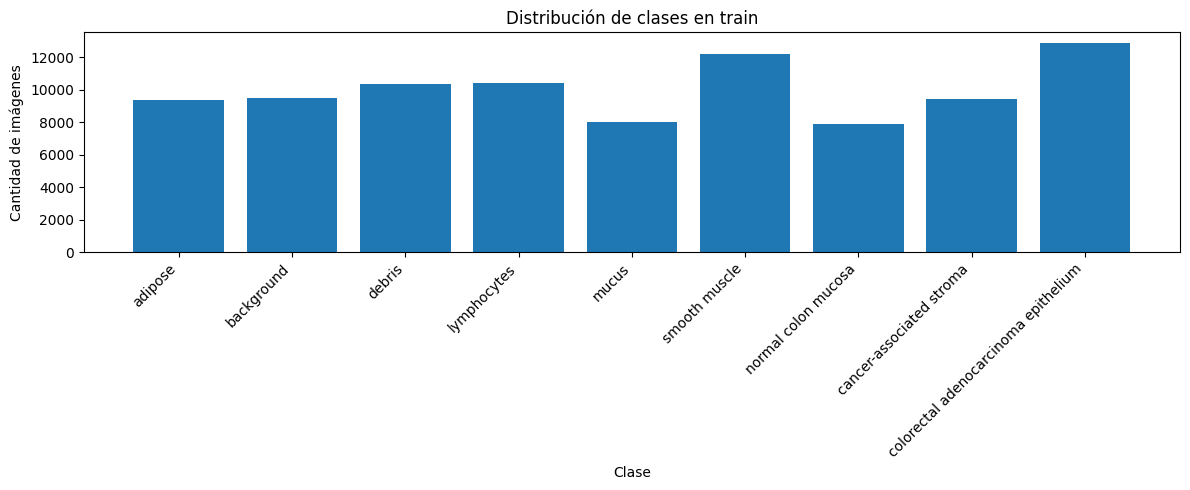

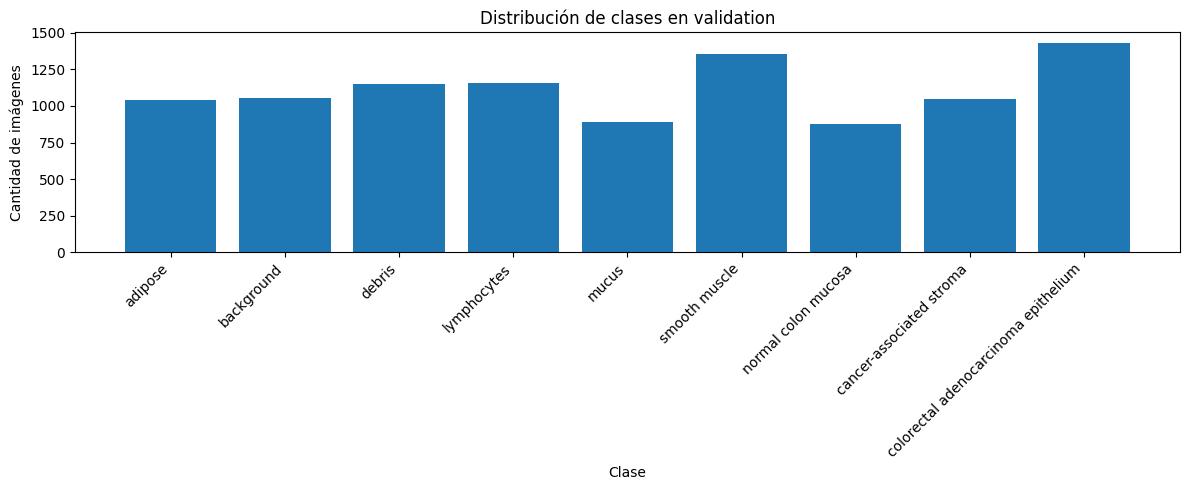

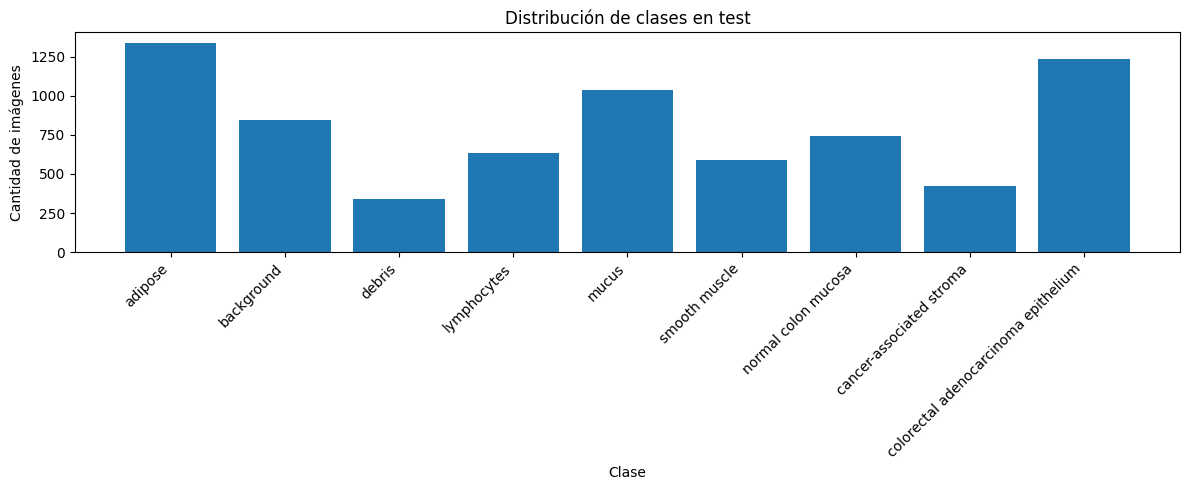

In [21]:
import matplotlib.pyplot as plt

for split_name in ["train", "validation", "test"]:
    split_data = class_distribution_df[
        class_distribution_df["split"] == split_name
    ].sort_values("class_id")
    
    plt.figure(figsize=(12, 5))
    plt.bar(split_data["class_name"], split_data["count"])
    plt.title(f"Distribución de clases en {split_name}")
    plt.xlabel("Clase")
    plt.ylabel("Cantidad de imágenes")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Comparación porcentual entre train, validation y test

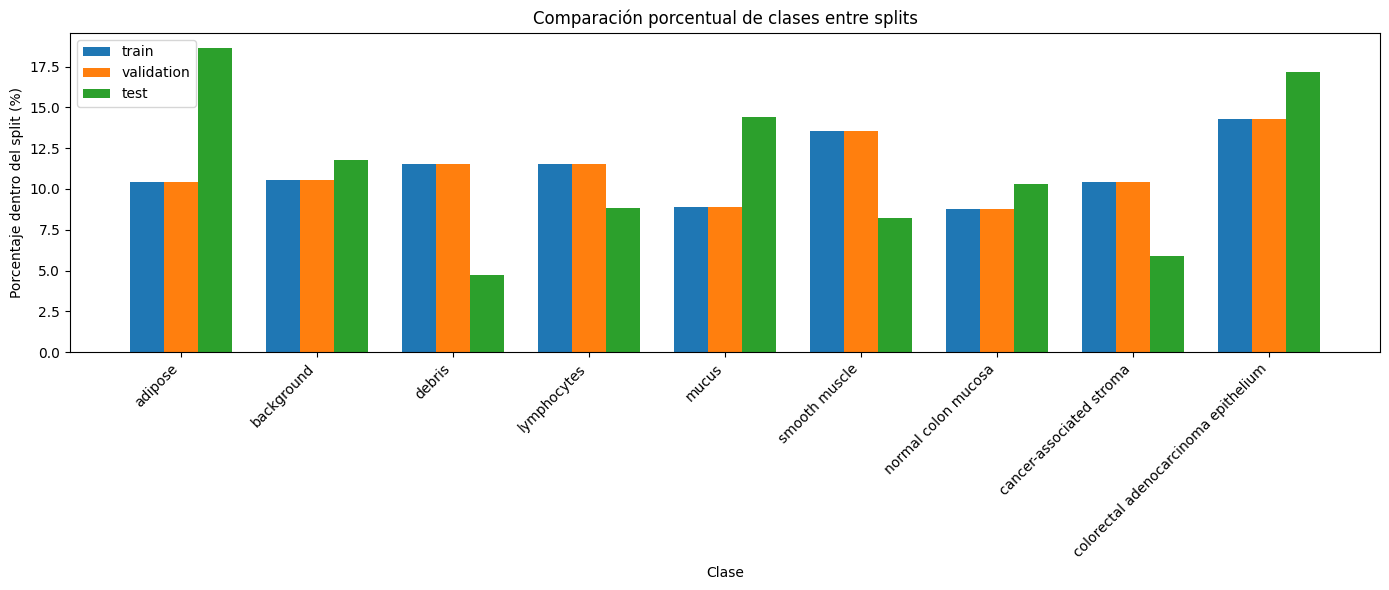

In [22]:
percentage_plot_df = class_percentage_pivot.copy()

x = np.arange(len(percentage_plot_df["class_name"]))
width = 0.25

plt.figure(figsize=(14, 6))

plt.bar(x - width, percentage_plot_df["train"], width, label="train")
plt.bar(x, percentage_plot_df["validation"], width, label="validation")
plt.bar(x + width, percentage_plot_df["test"], width, label="test")

plt.title("Comparación porcentual de clases entre splits")
plt.xlabel("Clase")
plt.ylabel("Porcentaje dentro del split (%)")
plt.xticks(x, percentage_plot_df["class_name"], rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Diferencia porcentual respecto a train

In [23]:
split_difference_df = class_percentage_pivot.copy()

split_difference_df["validation_minus_train"] = (
    split_difference_df["validation"] - split_difference_df["train"]
)

split_difference_df["test_minus_train"] = (
    split_difference_df["test"] - split_difference_df["train"]
)

split_difference_display = split_difference_df[
    [
        "class_id",
        "class_name",
        "train",
        "validation",
        "test",
        "validation_minus_train",
        "test_minus_train"
    ]
].copy()

for column in ["train", "validation", "test", "validation_minus_train", "test_minus_train"]:
    split_difference_display[column] = split_difference_display[column].round(2)

display(split_difference_display)

split,class_id,class_name,train,validation,test,validation_minus_train,test_minus_train
0,0,adipose,10.41,10.41,18.64,-0.0,8.23
1,1,background,10.57,10.57,11.80,-0.0,1.23
2,2,debris,11.51,11.52,4.72,0.0,-6.79
3,3,lymphocytes,11.56,11.56,8.83,-0.0,-2.73
4,4,mucus,8.90,8.90,14.42,0.0,5.52
5,5,smooth muscle,13.54,13.53,8.25,-0.0,-5.29
6,6,normal colon mucosa,8.76,8.77,10.32,0.0,1.56
7,7,cancer-associated stroma,10.45,10.45,5.86,-0.0,-4.58
8,8,colorectal adenocarcinoma epithelium,14.32,14.31,17.17,-0.0,2.86


## Validaciones automáticas de distribución

In [24]:
for split_name in ["train", "validation", "test"]:
    split_data = class_distribution_df[class_distribution_df["split"] == split_name]
    
    assert len(split_data) == n_classes, (
        f"Error en {split_name}: se esperaban {n_classes} clases, "
        f"pero se encontraron {len(split_data)}."
    )
    
    assert (split_data["count"] > 0).all(), (
        f"Error en {split_name}: existe al menos una clase sin muestras."
    )
    
    percentage_sum = split_data["percentage"].sum()
    
    assert np.isclose(percentage_sum, 100.0), (
        f"Error en {split_name}: los porcentajes no suman 100%. "
        f"Suma obtenida: {percentage_sum}."
    )

print("Validación de distribución superada: todas las clases están presentes en los tres splits y los porcentajes son consistentes.")

Validación de distribución superada: todas las clases están presentes en los tres splits y los porcentajes son consistentes.


## Conclusión de la Fase 4

El análisis de distribución de clases confirma que los tres splits oficiales de PathMNIST contienen las 9 clases esperadas. No se detectan clases ausentes en train, validation ni test, y las validaciones automáticas confirman que los porcentajes por split son consistentes.

En los conjuntos de **train** y **validation** se observa una distribución muy similar entre clases. Esto indica que validation conserva prácticamente la misma composición porcentual que train, por lo que resulta adecuado para monitorear el entrenamiento y apoyar la selección de hiperparámetros en etapas posteriores.

Sin embargo, el conjunto **test** presenta una distribución distinta y más desbalanceada. Mientras train y validation tienen un desbalance moderado, con ratios cercanos a 1.63, el conjunto test alcanza un `imbalance_ratio` de 3.947. En test, la clase mayoritaria es **adipose**, con 1.338 imágenes, mientras que la clase minoritaria es **debris**, con 339 imágenes.

Las diferencias porcentuales entre train y test son relevantes. Algunas clases aumentan considerablemente su representación en test, como **adipose** `(+8.23 puntos porcentuales)`, **mucus** `(+5.52)` y **colorectal adenocarcinoma epithelium** `(+2.86)`. En cambio, otras clases disminuyen de forma importante, como **debris** `(-6.79)`, **smooth muscle** `(-5.29)` y **cancer-associated stroma** `(-4.58)`.

Este hallazgo tiene una implicancia directa para la evaluación del modelo. Dado que test no conserva exactamente la misma distribución que train y validation, una métrica global como accuracy podría ocultar un bajo rendimiento en clases menos representadas. Por ello, en etapas posteriores será necesario complementar accuracy con métricas más informativas para clasificación multiclase, como **macro-F1**, **balanced accuracy**, **reporte por clase** y **matriz de confusión**.

En síntesis, PathMNIST presenta cobertura completa de clases en los tres splits, pero el conjunto test tiene una composición más desbalanceada y diferente respecto a train. Esta fase deja justificada la necesidad de evaluar el modelo no solo por desempeño global, sino también por desempeño específico en cada clase.

Con esto, el dataset queda caracterizado desde el punto de vista de soporte por clase.

# Fase 5 - Visualización cualitativa de imágenes

En esta fase se realiza una inspección visual inicial de las imágenes de PathMNIST.

El objetivo es observar ejemplos reales de las 9 clases del dataset para identificar patrones visuales preliminares, posibles similitudes entre clases y limitaciones asociadas a la resolución 28x28.

Esta fase responde las siguientes preguntas:

- ¿Cómo se ven las imágenes de cada clase?
- ¿Existen clases visualmente distinguibles?
- ¿Hay clases que parecen similares entre sí?
- ¿La resolución 28x28 conserva información suficiente para reconocer patrones generales?
- ¿Qué riesgos visuales podrían afectar el modelado posterior?

Esta fase no calcula todavía estadísticas RGB, no detecta anomalías de calidad de forma sistemática y no entrena modelos. Su propósito es entregar una primera lectura cualitativa del contenido visual del dataset.

## Imports para visualización

In [25]:
import matplotlib.pyplot as plt

## Función auxiliar para obtener etiquetas planas

In [26]:
def get_flat_labels(dataset):
    """
    Retorna las etiquetas de un split en formato plano.
    
    PathMNIST almacena las etiquetas con forma [N, 1].
    Para filtrar por clase, es más cómodo trabajar con forma [N].
    """
    
    return dataset.labels.reshape(-1)

## Función para seleccionar muestras por clase

In [27]:
def sample_indices_by_class(dataset, class_id, n_samples=6, seed=42):
    """
    Selecciona índices aleatorios de una clase específica dentro de un split.
    
    Parámetros:
    dataset: objeto PathMNIST.
    class_id: identificador numérico de la clase.
    n_samples: cantidad de imágenes a seleccionar.
    seed: semilla para reproducibilidad.
    
    Retorna:
    Array de índices seleccionados.
    """
    
    labels = get_flat_labels(dataset)
    class_indices = np.where(labels == class_id)[0]
    
    rng = np.random.default_rng(seed + int(class_id))
    
    sample_size = min(n_samples, len(class_indices))
    selected_indices = rng.choice(
        class_indices,
        size=sample_size,
        replace=False
    )
    
    return selected_indices

## Visualización de muestras por clase en train, validation y test

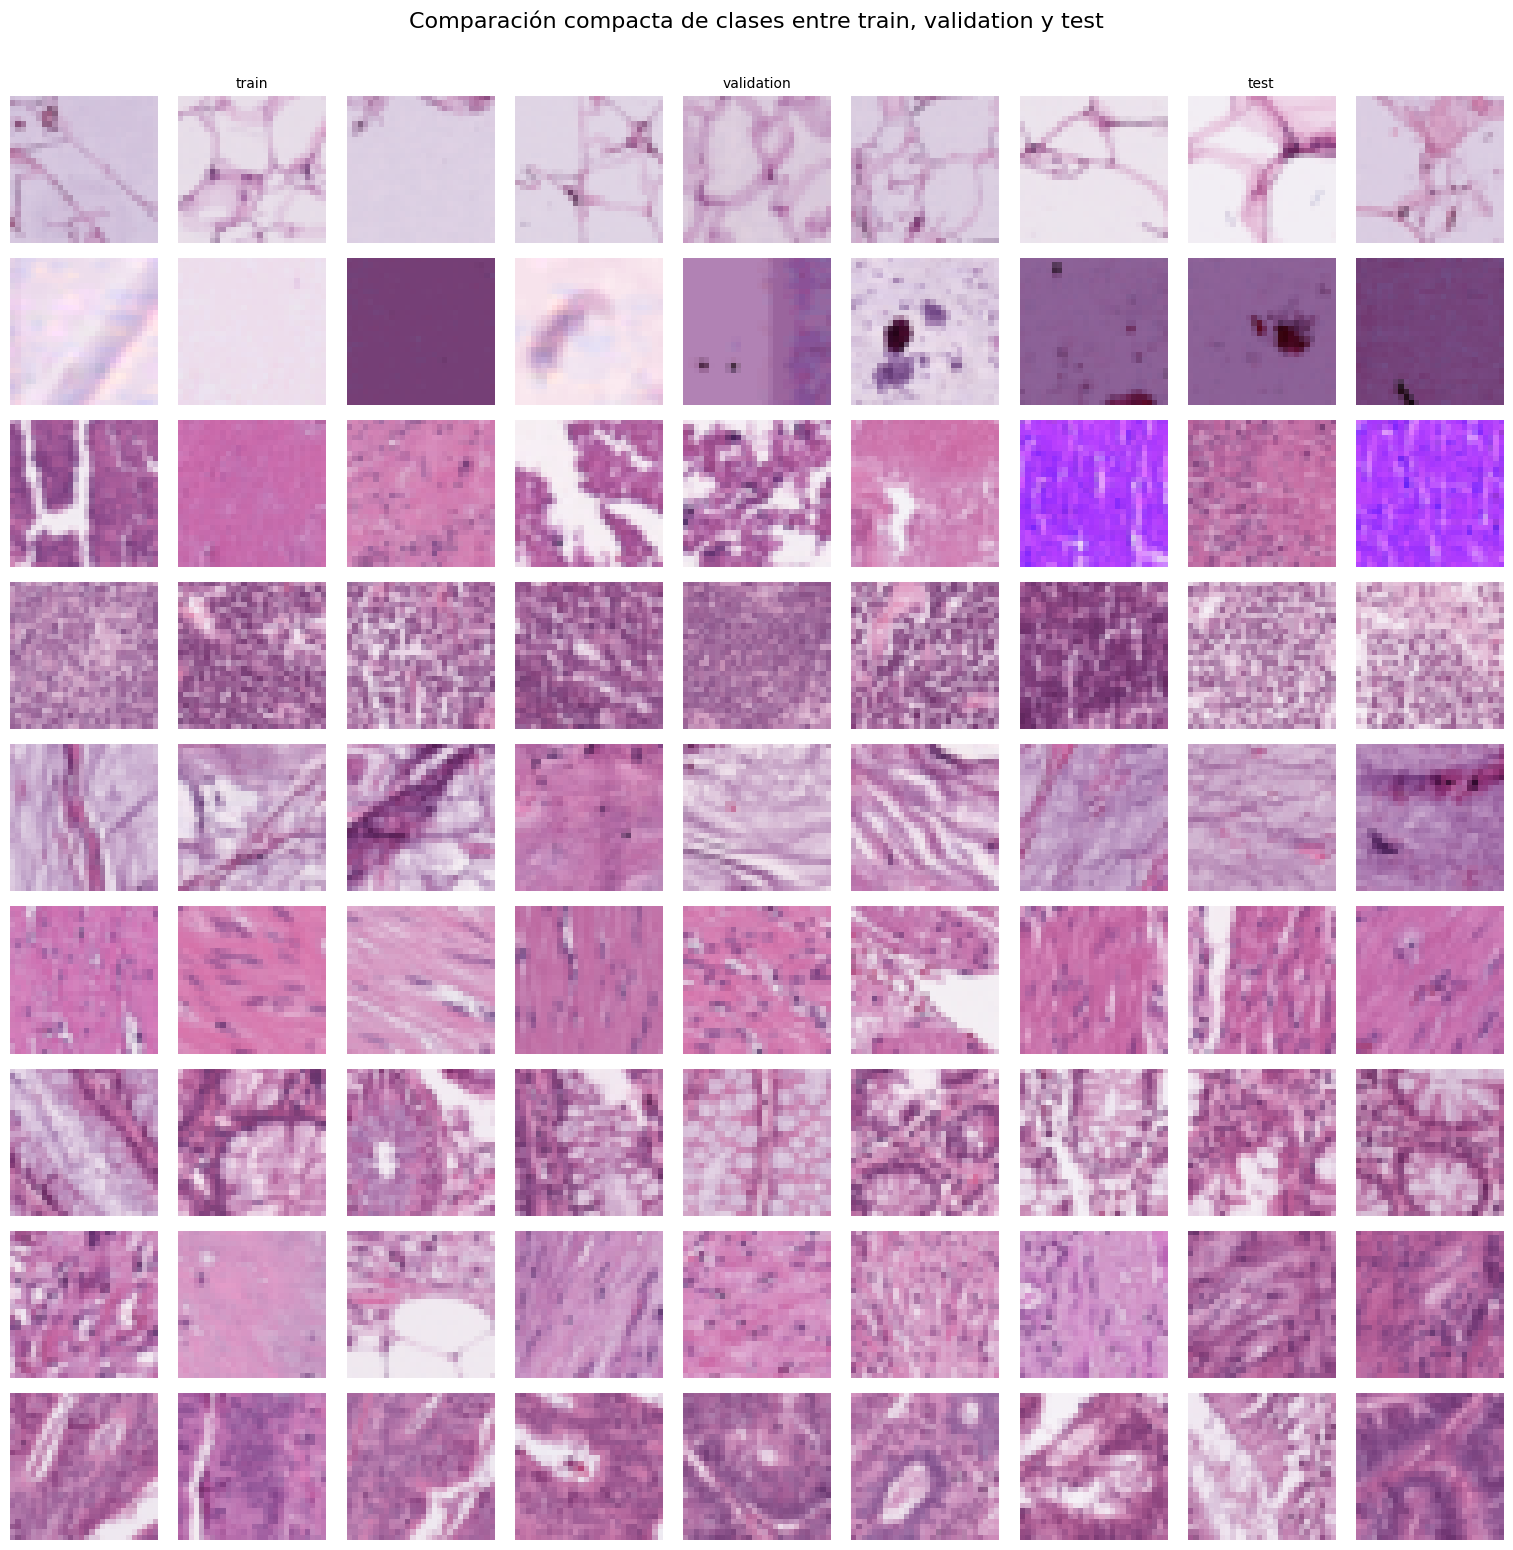

In [35]:
def plot_all_classes_across_splits(datasets, class_id_to_name, n_samples_per_split=3, seed=42):
    """
    Grafica una comparación compacta de todas las clases entre train, validation y test.

    Cada fila corresponde a una clase.
    Para cada clase se muestran muestras de train, validation y test.
    """

    split_names = ["train", "validation", "test"]
    n_classes_local = len(class_id_to_name)
    total_cols = len(split_names) * n_samples_per_split

    fig, axes = plt.subplots(
        nrows=n_classes_local,
        ncols=total_cols,
        figsize=(total_cols * 1.7, n_classes_local * 1.7)
    )

    for row_idx, (class_id, class_name) in enumerate(class_id_to_name.items()):
        for split_idx, split_name in enumerate(split_names):
            dataset = datasets[split_name]

            selected_indices = sample_indices_by_class(
                dataset=dataset,
                class_id=class_id,
                n_samples=n_samples_per_split,
                seed=seed + row_idx * 100 + split_idx * 10
            )

            for sample_idx in range(n_samples_per_split):
                col_idx = split_idx * n_samples_per_split + sample_idx
                ax = axes[row_idx, col_idx]

                if sample_idx < len(selected_indices):
                    image = dataset.imgs[selected_indices[sample_idx]]
                    ax.imshow(image)

                ax.axis("off")

                if row_idx == 0 and sample_idx == 1:
                    ax.set_title(split_name, fontsize=10)

                if col_idx == 0:
                    ax.set_ylabel(
                        f"{class_id}: {class_name}",
                        rotation=0,
                        labelpad=85,
                        va="center",
                        fontsize=9
                    )

    fig.suptitle(
        "Comparación compacta de clases entre train, validation y test",
        fontsize=16,
        y=1.01
    )

    plt.tight_layout()
    plt.show()


plot_all_classes_across_splits(
    datasets=datasets,
    class_id_to_name=class_id_to_name,
    n_samples_per_split=3,
    seed=SEED
)

## Visualización comparativa entre splits para una misma clase

In [29]:
def plot_class_across_splits(datasets, class_id, class_id_to_name, n_samples=5, seed=42):
    """
    Grafica muestras de una misma clase en train, validation y test.
    
    Cada fila corresponde a un split.
    Cada columna corresponde a una muestra aleatoria de la clase seleccionada.
    """
    
    split_names = ["train", "validation", "test"]
    class_name = class_id_to_name[class_id]
    
    fig, axes = plt.subplots(
        nrows=len(split_names),
        ncols=n_samples,
        figsize=(n_samples * 2.2, len(split_names) * 2.2)
    )
    
    for row_idx, split_name in enumerate(split_names):
        dataset = datasets[split_name]
        
        selected_indices = sample_indices_by_class(
            dataset=dataset,
            class_id=class_id,
            n_samples=n_samples,
            seed=seed + row_idx * 100
        )
        
        for col_idx in range(n_samples):
            ax = axes[row_idx, col_idx]
            
            if col_idx < len(selected_indices):
                image = dataset.imgs[selected_indices[col_idx]]
                ax.imshow(image)
            
            ax.axis("off")
            
            if col_idx == 0:
                ax.set_ylabel(
                    split_name,
                    rotation=0,
                    labelpad=50,
                    va="center"
                )
    
    fig.suptitle(
        f"Comparación visual entre splits — Clase {class_id}: {class_name}",
        fontsize=15,
        y=1.02
    )
    
    plt.tight_layout()
    plt.show()

## Comparación entre splits para clases seleccionadas

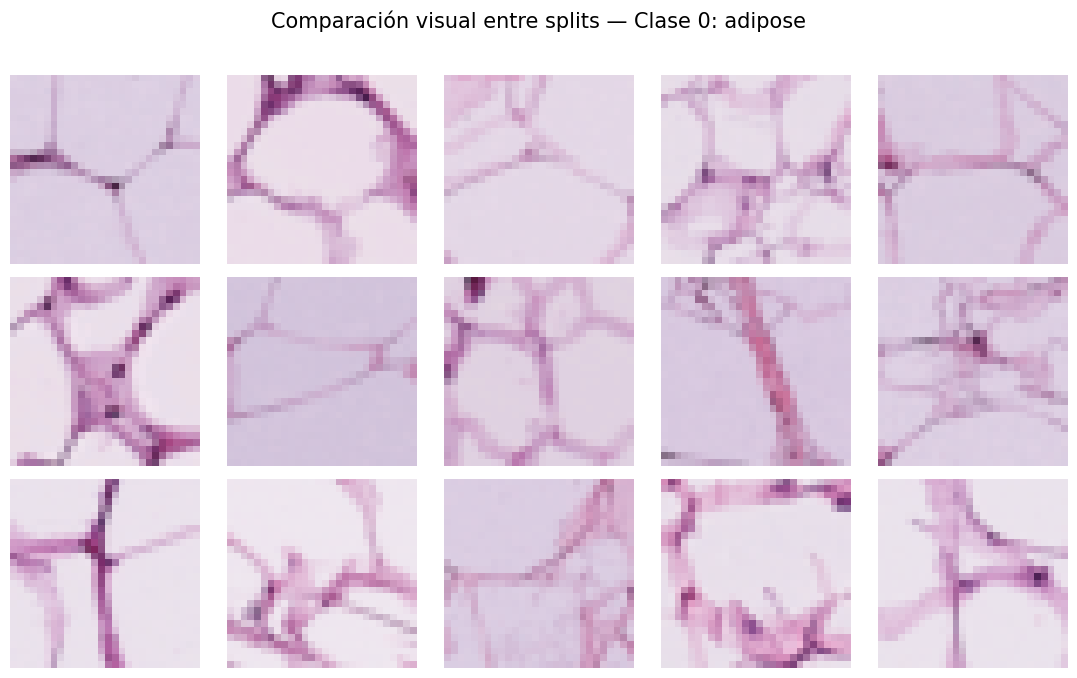

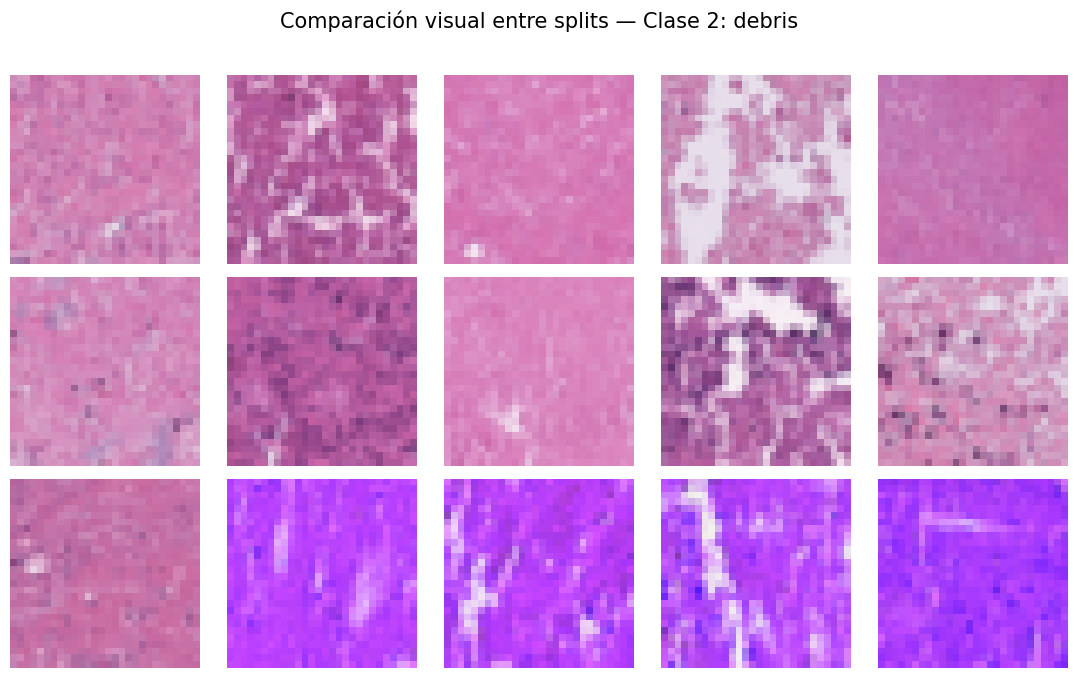

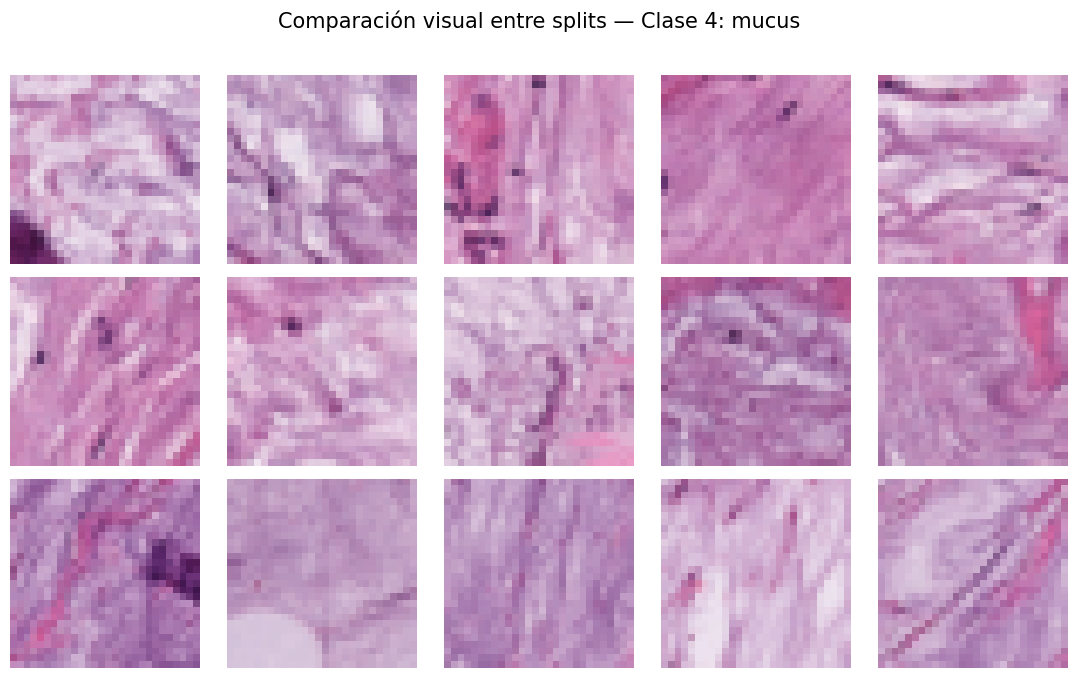

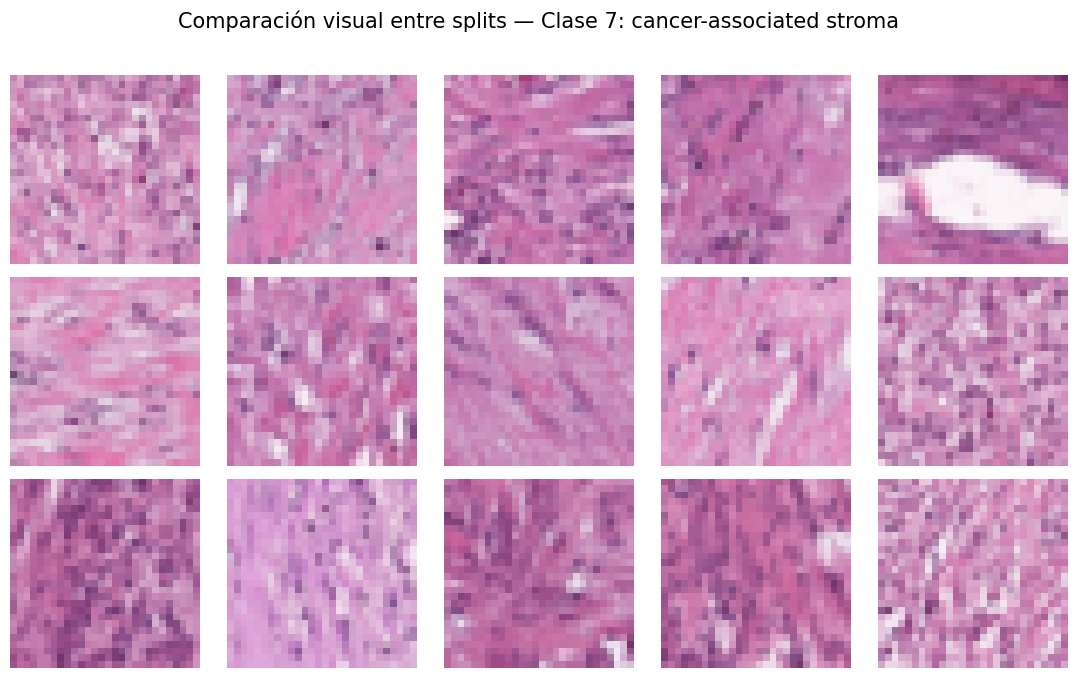

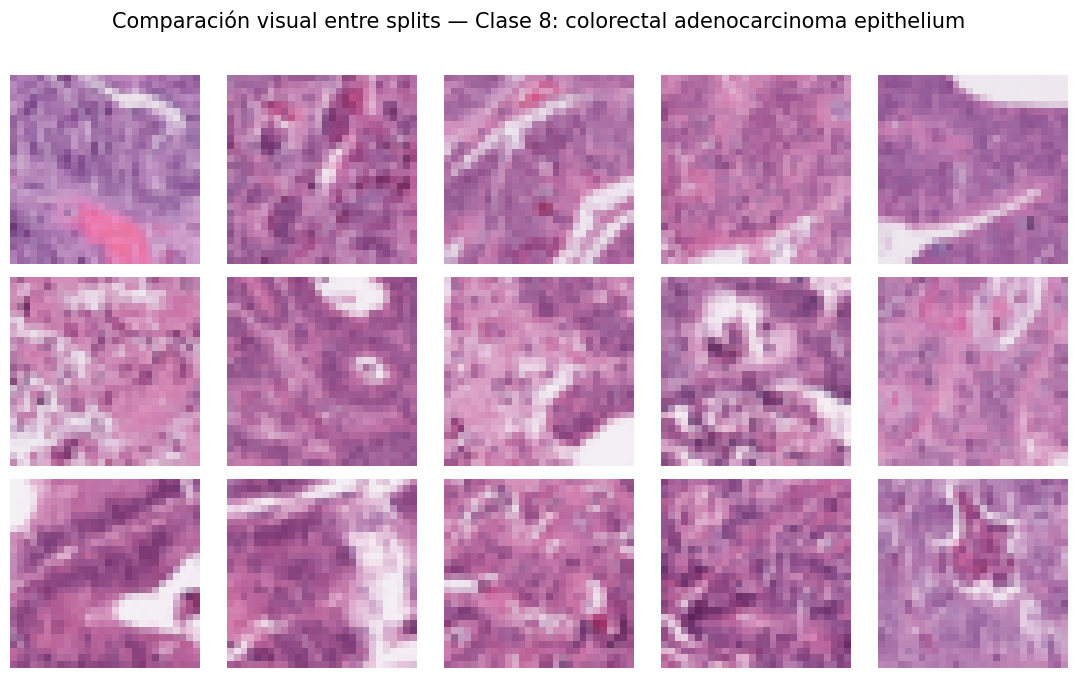

In [30]:
selected_classes_for_split_comparison = [
    0,  # adipose
    2,  # debris
    4,  # mucus
    7,  # cancer-associated stroma
    8   # colorectal adenocarcinoma epithelium
]

for class_id in selected_classes_for_split_comparison:
    plot_class_across_splits(
        datasets=datasets,
        class_id=class_id,
        class_id_to_name=class_id_to_name,
        n_samples=5,
        seed=SEED
    )

## Muestras aleatorias generales por split

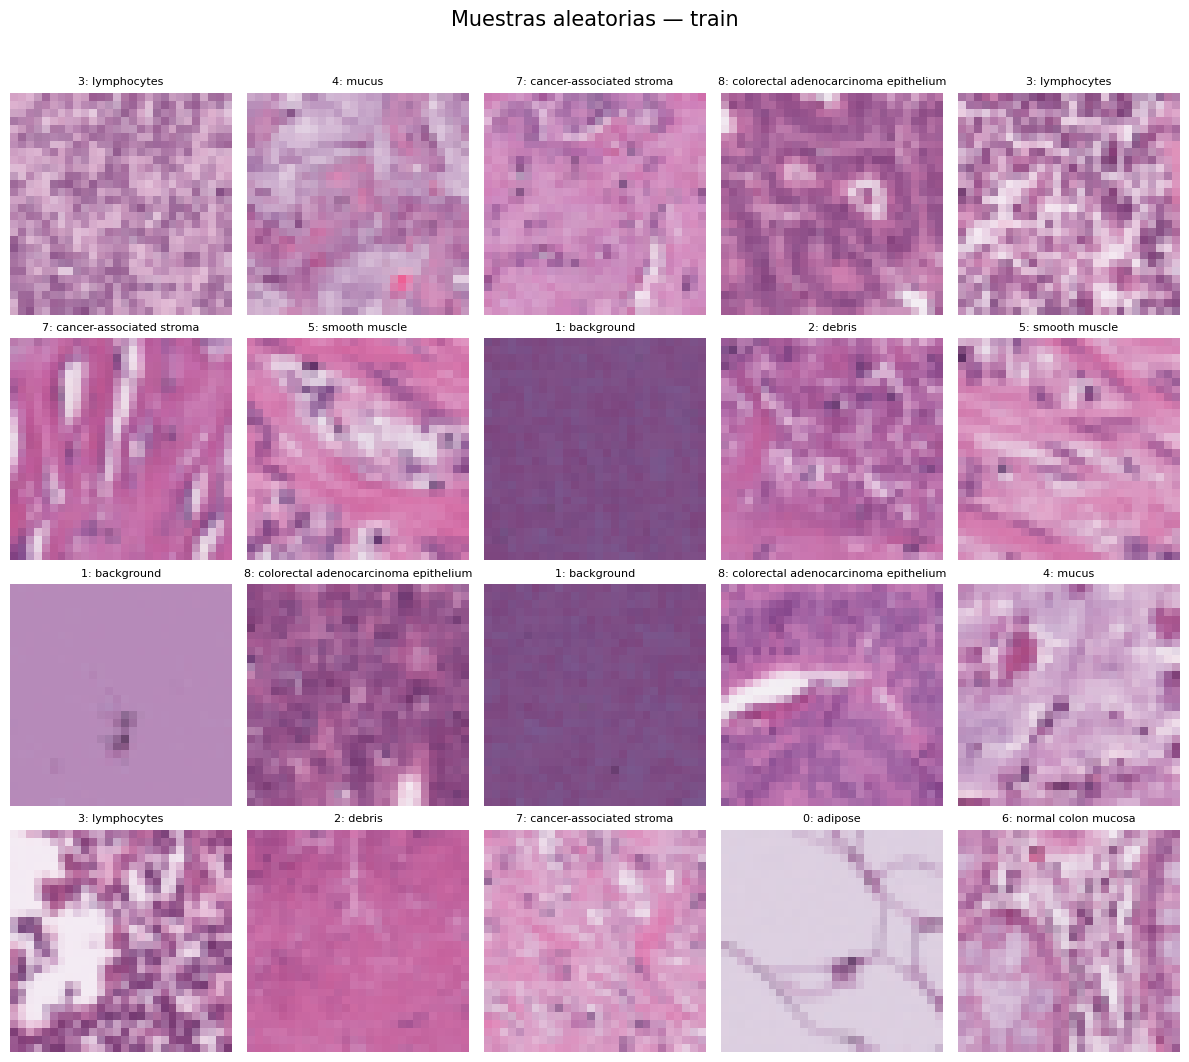

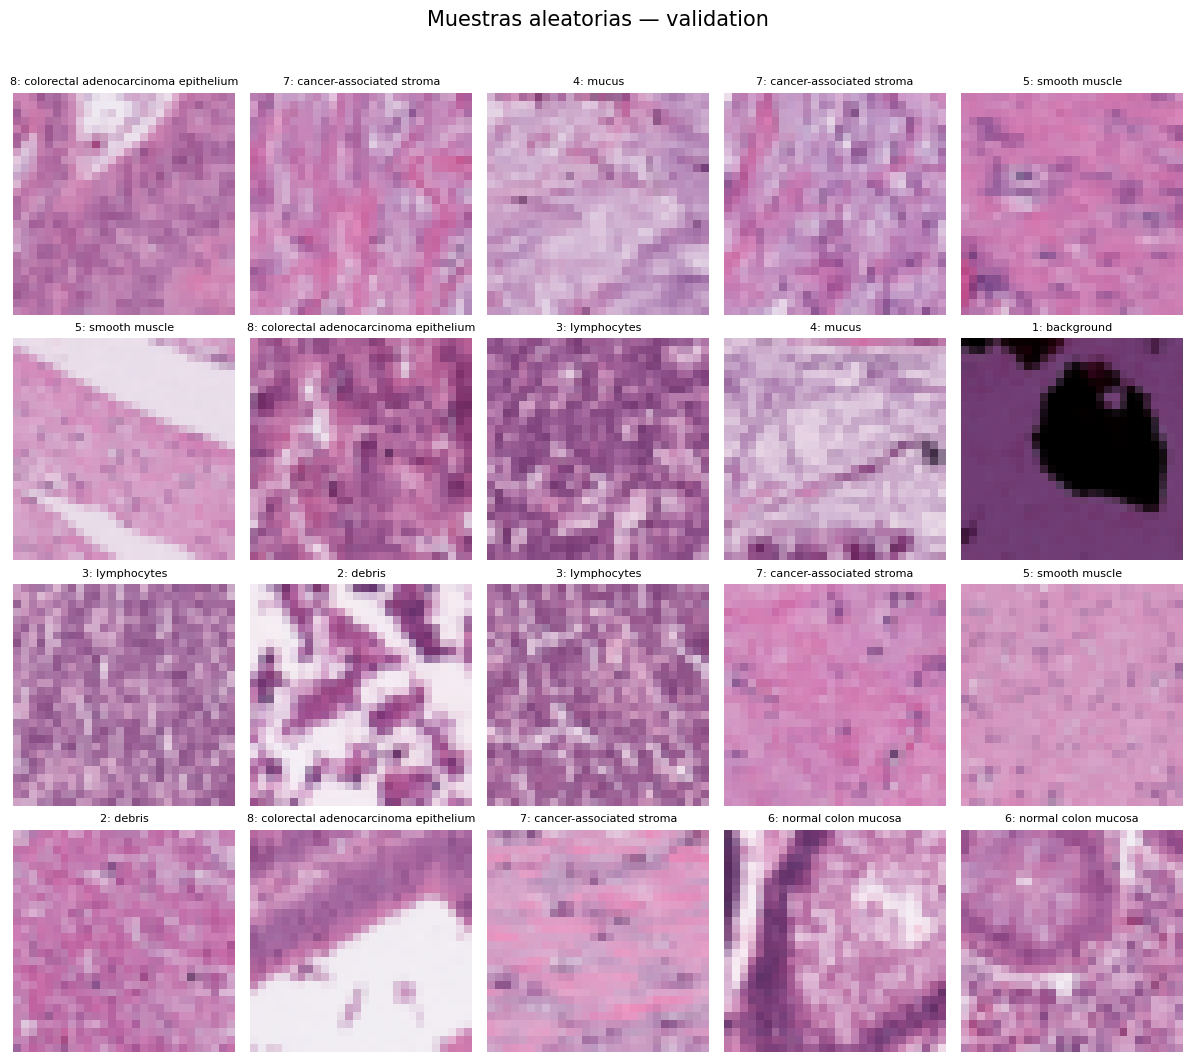

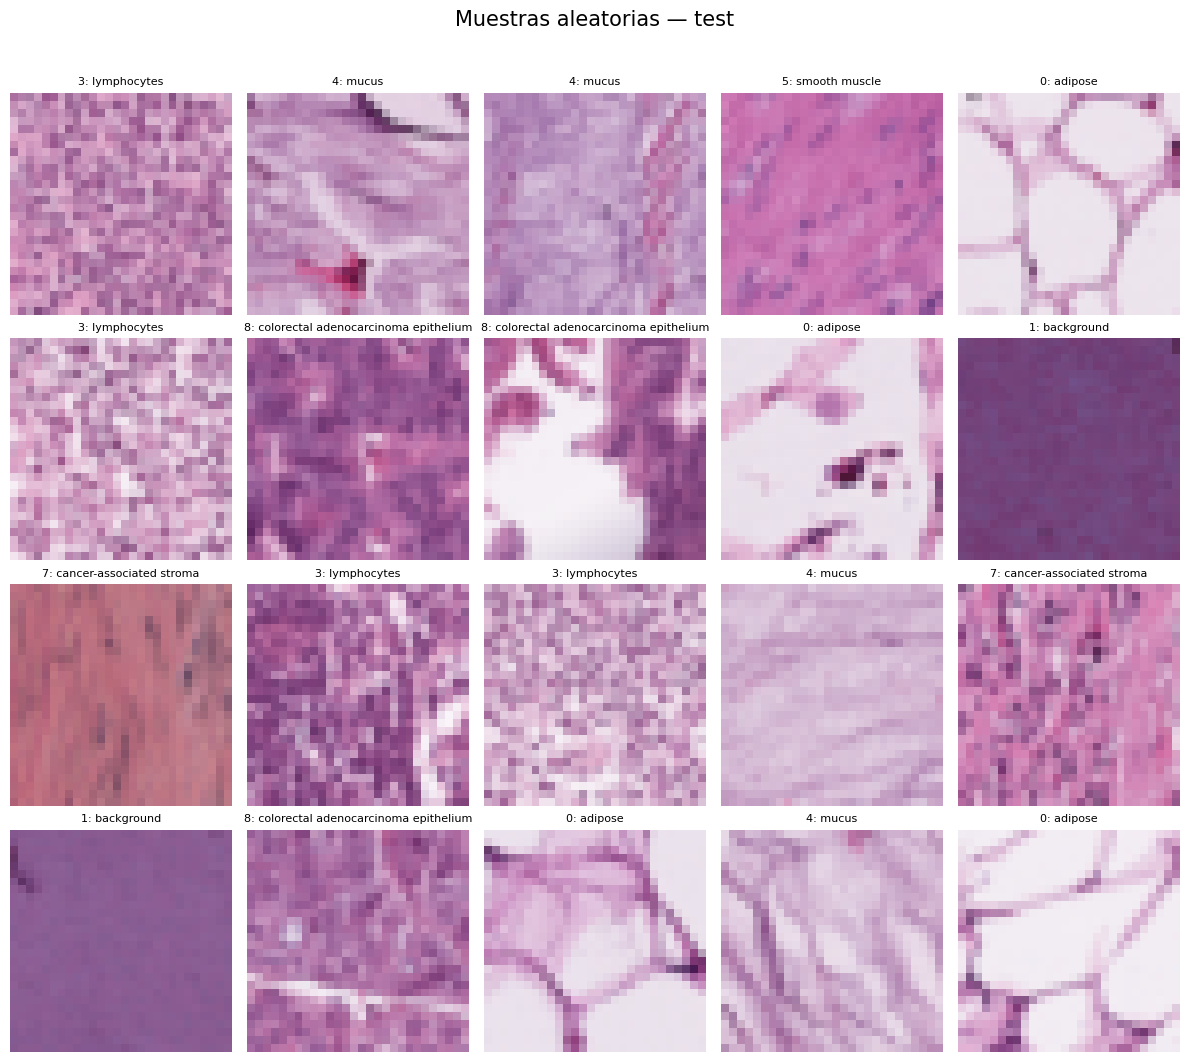

In [31]:
def plot_random_samples_from_split(dataset, split_name, class_id_to_name, n_samples=20, seed=42):
    """
    Grafica muestras aleatorias de un split, mostrando la clase asociada.
    """
    
    rng = np.random.default_rng(seed)
    total_samples = len(dataset.imgs)
    
    selected_indices = rng.choice(
        np.arange(total_samples),
        size=min(n_samples, total_samples),
        replace=False
    )
    
    n_cols = 5
    n_rows = int(np.ceil(len(selected_indices) / n_cols))
    
    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(n_cols * 2.4, n_rows * 2.6)
    )
    
    axes = np.array(axes).reshape(-1)
    labels = get_flat_labels(dataset)
    
    for ax_idx, ax in enumerate(axes):
        if ax_idx < len(selected_indices):
            idx = selected_indices[ax_idx]
            image = dataset.imgs[idx]
            class_id = int(labels[idx])
            class_name = class_id_to_name[class_id]
            
            ax.imshow(image)
            ax.set_title(f"{class_id}: {class_name}", fontsize=8)
        
        ax.axis("off")
    
    fig.suptitle(
        f"Muestras aleatorias — {split_name}",
        fontsize=15,
        y=1.02
    )
    
    plt.tight_layout()
    plt.show()


plot_random_samples_from_split(
    dataset=train_dataset,
    split_name="train",
    class_id_to_name=class_id_to_name,
    n_samples=20,
    seed=SEED
)

plot_random_samples_from_split(
    dataset=val_dataset,
    split_name="validation",
    class_id_to_name=class_id_to_name,
    n_samples=20,
    seed=SEED
)

plot_random_samples_from_split(
    dataset=test_dataset,
    split_name="test",
    class_id_to_name=class_id_to_name,
    n_samples=20,
    seed=SEED
)

## Validación mínima de visualización

In [33]:
visual_check_rows = []

for split_name, dataset in datasets.items():
    images = dataset.imgs
    
    visual_check_rows.append({
        "split": split_name,
        "image_shape_per_sample": images.shape[1:],
        "compatible_with_imshow": images.ndim == 4 and images.shape[-1] == 3,
        "pixel_min": images.min(),
        "pixel_max": images.max()
    })

visual_check_df = pd.DataFrame(visual_check_rows)

display(visual_check_df)

,split,image_shape_per_sample,compatible_with_imshow,pixel_min,pixel_max
0,train,"(28, 28, 3)",True,0,255
1,validation,"(28, 28, 3)",True,0,255
2,test,"(28, 28, 3)",True,0,255


## Conclusión de la Fase 5

La visualización cualitativa de PathMNIST confirma que las imágenes conservan patrones visuales relevantes a pesar de trabajar con una resolución reducida de 28x28 píxeles. Aunque esta resolución limita el detalle histológico fino, todavía permite distinguir diferencias generales de color, textura, densidad celular y organización tisular que pueden ser útiles para el aprendizaje supervisado.

La comparación compacta de clases entre **train, validation y test** muestra que varias categorías mantienen una apariencia visual relativamente consistente a través de los tres splits. Por ejemplo, **adipose** presenta de forma recurrente grandes regiones claras separadas por bordes delgados rosados o violáceos, lo que la convierte en una clase visualmente bastante distinguible. De forma similar, **background** suele corresponder a regiones homogéneas o casi uniformes, con muy poca estructura tisular visible, lo que también sugiere una separación visual relativamente clara respecto a otras clases.

En contraste, clases como **debris**, **mucus**, **normal colon mucosa**, **cancer-associated stroma** y **colorectal adenocarcinoma epithelium** presentan una mayor variabilidad interna y también similitudes entre sí. Estas clases comparten, en distintos grados, texturas rosadas o violáceas, estructuras irregulares y niveles variables de densidad celular, lo que sugiere que el problema de clasificación no dependerá solamente de patrones morfológicos simples, sino de combinaciones más sutiles de textura, color y organización local.

La comparación entre splits también aporta información importante. En varias clases, la apariencia general se mantiene razonablemente estable entre train, validation y test; sin embargo, en otras se aprecian diferencias visuales que merecen atención. En particular, algunas muestras de **debris** en test muestran tonalidades más intensas o más cercanas al violeta que varios ejemplos observados en train y validation. Además, en la clase **background** aparecen ejemplos con regiones oscuras muy marcadas o áreas casi completamente uniformes, especialmente en validation y test. Estas observaciones no permiten concluir todavía la existencia de un cambio de dominio de forma definitiva, pero sí justifican que en las siguientes fases se analicen cuantitativamente las distribuciones de color, brillo e intensidad mediante estadísticas RGB y auditoría de calidad visual.

La visualización de muestras aleatorias por split refuerza dos ideas centrales. Primero, el dataset contiene clases con distinto nivel de complejidad visual: algunas son relativamente homogéneas, mientras que otras muestran una variabilidad considerable. Segundo, existen ejemplos extremos o poco representativos visualmente, como fondos muy oscuros, áreas casi uniformes o parches con contraste muy marcado. Estos casos no deben eliminarse en esta etapa, pero sí deben considerarse más adelante al revisar calidad de datos y posibles outliers visuales.

Un hallazgo adicional importante es que varias clases potencialmente relevantes para el problema clínico, como **cancer-associated stroma**, **normal colon mucosa** y **colorectal adenocarcinoma epithelium**, muestran patrones que pueden resultar visualmente cercanos en resolución 28x28. Esto sugiere que el modelo podría tener mayores dificultades para separar clases histológicamente complejas o con fronteras visuales sutiles, en comparación con clases más fácilmente distinguibles como **adipose** o **background**.

La validación mínima de visualización confirma además que las imágenes de train, validation y test tienen forma `(28, 28, 3)`, son compatibles con visualización directa y conservan valores de píxel entre 0 y 255. Esto asegura que las observaciones cualitativas realizadas corresponden a los datos originales cargados, sin transformaciones de normalización ni preprocesamiento adicional.

En síntesis, la inspección visual confirma que PathMNIST contiene señales visuales suficientes para tareas de clasificación, pero también evidencia tres aspectos clave:  
1. la resolución 28x28 conserva patrones generales, aunque limita el detalle histológico fino;  
2. algunas clases son visualmente más distinguibles que otras;  
3. existen variaciones visuales y posibles diferencias cromáticas entre splits que deberán analizarse cuantitativamente más adelante.

Con esto, el dataset queda caracterizado desde una perspectiva visual preliminar y preparado para la siguiente fase del EDA: **Fase 8 — Estadísticas globales de píxeles y canales RGB**.++